# dPCA — Trayectorias poblacionales por orientación
Perez-Becerra et al. 2025 — calcio V1, BTBR vs C57

**Instalación:** `pip install git+https://github.com/machenslab/dPCA.git#subdirectory=python`

**Orden de ejecución:** celdas 1 → 2 → 3 → 4 → 5 → 6 → 7


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import pdist
from scipy import stats
import traceback
import warnings
warnings.filterwarnings('ignore')

try:
    from dPCA import dPCA as dPCA_module
    print("dPCA disponible.")
except ImportError:
    dPCA_module = None
    print("dPCA no instalado.")
    print("pip install git+https://github.com/machenslab/dPCA.git#subdirectory=python")


dPCA disponible.


## 2. Configuracion — edita solo esta celda

In [20]:
# ─── RUTAS ───────────────────────────────────────────────────────────────────
DATA_ROOT      = r'D:\AL-205\Nicole\Calcio_raw\Calcio'
SCOPE_KEYWORD  = 'reg'
STIM_KEYWORD   = 'pas'
TRACES_KEYWORD = 'traces'
GENOTYPE_FOLDERS = {'BTBR': 'BTBR', 'C57': 'C57'}

# ─── ADQUISICIÓN ─────────────────────────────────────────────────────────────
SAMPLING_RATE = 5
MS_PER_FRAME  = 1000 / SAMPLING_RATE

# ─── VENTANAS ────────────────────────────────────────────────────────────────
SEC_BEFORE    = 2
SEC_AFTER     = 4
FRAMES_BEFORE = int(SEC_BEFORE * SAMPLING_RATE)
FRAMES_AFTER  = int(SEC_AFTER  * SAMPLING_RATE)
TOTAL_FRAMES  = FRAMES_BEFORE + FRAMES_AFTER
RESP_START    = FRAMES_BEFORE
RESP_END      = TOTAL_FRAMES

# ─── NORMALIZACIÓN ───────────────────────────────────────────────────────────
NORMALIZATION   = 'dff'
RESPONSIVE_STD  = 2.5
R2_THRESH       = 0.7

# ─── dPCA ────────────────────────────────────────────────────────────────────
SIGMA_MS     = 200   # suavizado gaussiano en ms (200ms = Perez-Becerra)
N_COMPONENTS = 3     # dPCs por marginalizacion
SIGNIFICANCE = False # True solo si N_neuronas <= 150 (es lento)
N_SPLITS     = 10

# ─── OUTPUT / ESTÉTICA ───────────────────────────────────────────────────────
OUTPUT_DIR = Path(DATA_ROOT) / 'dpca_output'
OUTPUT_DIR.mkdir(exist_ok=True)
PALETTE    = {'BTBR': '#e74c3c', 'C57': '#3498db', 'Unknown': '#95a5a6'}
ORIENT_COLORS = {
    0:   '#e74c3c',   # rojo
    45:  '#2ecc71',   # verde
    90:  '#3498db',   # azul
    135: '#f1c40f',   # amarillo
}

print('Configuracion lista.')
print('Output ->', OUTPUT_DIR)


Configuracion lista.
Output -> D:\AL-205\Nicole\Calcio_raw\Calcio\dpca_output


## 3. Pipeline de carga (identico al pipeline principal)

In [3]:
# ── helpers ──────────────────────────────────────────────────────────────────
def _hms_to_ms(s):
    h, m, sec = map(int, s.strip().split(':'))
    return (h * 3600 + m * 60 + sec) * 1000.0

def find_file(folder, keyword):
    kw = keyword.lower()
    matches = [f for f in folder.iterdir() if f.is_file() and kw in f.name.lower()]
    if not matches:
        raise FileNotFoundError(f"No encontre '{keyword}' en {folder}")
    txt = [f for f in matches if f.suffix.lower() == '.txt']
    csv = [f for f in matches if f.suffix.lower() == '.csv']
    return (txt[0] if txt else matches[0]) if kw in ['reg','pas'] else (csv[0] if csv else matches[0])

def detect_genotype(name):
    for kw, g in GENOTYPE_FOLDERS.items():
        if kw.upper() in name.upper():
            return g
    return 'Unknown'

def discover_animals(root):
    root = Path(root)
    out  = []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith('.') or group.name in ('pipeline_output','dpca_output'):
            continue
        geno = detect_genotype(group.name)
        for animal in sorted(group.iterdir()):
            if animal.is_dir() and not animal.name.startswith('.'):
                out.append({'animal_id': animal.name, 'genotype': geno,
                            'group': group.name, 'folder': animal})
    return out

def parse_scope_txt(filepath):
    lines = open(filepath, encoding='utf-8', errors='ignore').readlines()
    ts_abs, ms_list, flags = [], [], []
    for line in lines:
        p = line.strip().split('.')
        if len(p) < 5: continue
        t = _hms_to_ms(p[0]) + float(p[1]) / 1000.0
        ts_abs.append(t); ms_list.append(t); flags.append(float(p[3]))
    ts_abs = np.array(ts_abs)
    return None, ts_abs, ts_abs - ts_abs[0], np.array(flags)

def parse_stim_txt(filepath):
    lines = open(filepath, encoding='utf-8', errors='ignore').readlines()
    ts_abs, estimulos = [], []
    for line in lines:
        p = line.strip().split('.')
        if len(p) < 3: continue
        t   = _hms_to_ms(p[0]) + float(p[1])
        raw = p[2].strip()
        val = 11 if raw == '11' else (int(raw.lstrip('0')) if raw.lstrip('0') else 0)
        ts_abs.append(t); estimulos.append(float(val))
    return None, np.array(ts_abs), np.array(estimulos)

def get_frames_abs(ts_ms, flags, min_gap=100.0):
    idx  = np.where(flags == 23)[0]
    t    = ts_ms[idx]
    keep = np.where(np.diff(t) > min_gap)[0] + 1
    return np.insert(t[keep], 0, t[0])

def get_frames_rel(ms_rel, flags, min_gap=100.0):
    idx  = np.where(flags == 23)[0]
    t    = ms_rel[idx]
    keep = np.where(np.diff(t) > min_gap)[0] + 1
    return np.insert(t[keep], 0, t[0])

def align_stimuli(ts_ms_scope, ms_rel, flags, ts_ms_stim, estimulos):
    from collections import defaultdict
    t_abs    = get_frames_abs(ts_ms_scope, flags)
    idx_11   = np.where(estimulos == 11)[0]
    records, n_bad = [], 0
    for idx in idx_11:
        diffs = np.abs(t_abs - ts_ms_stim[idx])
        near  = int(np.argmin(diffs))
        if diffs[near] > 500: n_bad += 1; continue
        angle = None
        for k in range(idx+1, min(idx+5, len(estimulos))):
            if estimulos[k] != 11: angle = int(estimulos[k]); break
        if angle is None:
            for k in range(idx-1, max(idx-5,-1), -1):
                if estimulos[k] != 11: angle = int(estimulos[k]); break
        if angle is None: n_bad += 1; continue
        records.append((angle, near))
    if not records:
        raise ValueError("Sin trials alineables. Revisa timestamps.")
    by_angle = defaultdict(list)
    for ang, fr in records: by_angle[ang].append(fr)
    angles   = sorted(by_angle.keys())
    n_trials = min(len(by_angle[a]) for a in angles)
    sf       = np.zeros((len(angles), n_trials, 2), dtype=int)
    for ai, ang in enumerate(angles):
        sf[ai,:,0] = ang
        sf[ai,:,1] = by_angle[ang][:n_trials]
    return sf, n_bad

def normalize_trial(F, frames_before, method='dff'):
    bl = F[:frames_before]
    if method == 'zscore':
        mu = np.mean(bl, axis=0); sd = np.std(bl, axis=0)
        return (F - mu) / (sd + 1e-6)
    F0 = np.median(bl, axis=0)
    return (F - F0) / (np.abs(F0) + 1e-6)

def extract_signals(traces_csv, stimsnframes, frames_before=FRAMES_BEFORE,
                    frames_after=FRAMES_AFTER, normalization=NORMALIZATION):
    df = pd.read_csv(traces_csv, decimal=',', sep=None, engine='python')
    if df.columns[0].lower() in ['unnamed: 0','index','time','frame']:
        df.drop(df.columns[0], axis=1, inplace=True)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
    N_frames = len(df); out = {}; n_excl = 0
    for ai in range(stimsnframes.shape[0]):
        for ti in range(stimsnframes.shape[1]):
            ang = int(stimsnframes[ai,ti,0]); sf = int(stimsnframes[ai,ti,1])
            s = sf - frames_before; e = sf + frames_after
            if s < 0 or e > N_frames: n_excl += 1; continue
            sig = normalize_trial(df.iloc[s:e].values.copy(), frames_before, normalization)
            out.setdefault(ang, []).append(sig)
    if n_excl: print(f'  Trials excluidos por borde: {n_excl}')
    for ang in out:
        stk = np.stack(out[ang], axis=-1)          # (T, N, trials)
        out[ang] = np.transpose(stk, (1, 0, 2))    # (N, T, trials)
    return out

def find_responsive(extracted_data, threshold_std=RESPONSIVE_STD):
    n_neurons = next(iter(extracted_data.values())).shape[0]
    resp = []
    for n in range(n_neurons):
        ok = False
        for ang, data in extracted_data.items():
            if ok: break
            d = data[n]; n_ok = 0
            for t in range(d.shape[1]):
                thr = np.std(d[:FRAMES_BEFORE, t]) * threshold_std
                if np.mean(d[RESP_START:RESP_END, t]) > thr: n_ok += 1
            if n_ok >= max(1, d.shape[1] / 2): ok = True
        if ok: resp.append(n)
    return resp

print("Funciones de carga listas.")


Funciones de carga listas.


## 4. Cargar todos los animales

In [4]:
animals    = discover_animals(DATA_ROOT)
animal_data = {}
failed      = []

print(f'Animales encontrados: {len(animals)}')
for a in animals:
    print(f"  [{a['genotype']:6}]  {a['group']}/{a['animal_id']}")

print()
for animal in animals:
    aid  = animal['animal_id']
    geno = animal['genotype']
    print(f"  {aid} [{geno}]...", end=' ')
    try:
        scope_f  = find_file(animal['folder'], SCOPE_KEYWORD)
        stim_f   = find_file(animal['folder'], STIM_KEYWORD)
        traces_f = find_file(animal['folder'], TRACES_KEYWORD)

        _, ts_ms_scope, ms_rel, flags = parse_scope_txt(scope_f)
        _, ts_ms_stim, estimulos      = parse_stim_txt(stim_f)

        sf, n_bad = align_stimuli(ts_ms_scope, ms_rel, flags, ts_ms_stim, estimulos)
        ext       = extract_signals(traces_f, sf)

        if not ext:
            print("sin datos — saltando"); failed.append(aid); continue

        resp = find_responsive(ext)
        n_neurons = next(iter(ext.values())).shape[0]
        print(f"{n_neurons} neuronas, {len(resp)} responsivas, {len(sf[0])} trials/angulo")

        animal_data[aid] = {'extracted_data': ext, 'responsive': resp, 'genotype': geno}

    except Exception:
        print("ERROR"); traceback.print_exc(); failed.append(aid)

print(f"\nCargados: {len(animal_data)}  Fallidos: {failed}")


Animales encontrados: 15
  [BTBR  ]  BTBR_V1/BTBRL1_03_08_25
  [BTBR  ]  BTBR_V1/BTBRR1_13_01_26
  [BTBR  ]  BTBR_V1/BTBRR1_28_08_25
  [BTBR  ]  BTBR_V1/BTBRR2_06_07_25
  [BTBR  ]  BTBR_V1/BTBRR2_27_09_23
  [BTBR  ]  BTBR_V1/BTBRSM_27_09_23
  [C57   ]  C57_V1/C57L1_30_03_25
  [C57   ]  C57_V1/C57L2_27_09_23
  [C57   ]  C57_V1/C57L3_23_08_25
  [C57   ]  C57_V1/C57R1_13_01_26
  [C57   ]  C57_V1/C57R1_23_08_25
  [C57   ]  C57_V1/C57R2_01_05_25
  [C57   ]  C57_V1/C57R2_19_01_25
  [C57   ]  C57_V1/C57R2_27_02_26
  [C57   ]  C57_V1/C57SM_27_09_23

  BTBRL1_03_08_25 [BTBR]...   Trials excluidos por borde: 4
60 neuronas, 7 responsivas, 10 trials/angulo
  BTBRR1_13_01_26 [BTBR]...   Trials excluidos por borde: 51
87 neuronas, 59 responsivas, 10 trials/angulo
  BTBRR1_28_08_25 [BTBR]...   Trials excluidos por borde: 30
106 neuronas, 43 responsivas, 10 trials/angulo
  BTBRR2_06_07_25 [BTBR]... 187 neuronas, 139 responsivas, 10 trials/angulo
  BTBRR2_27_09_23 [BTBR]... 93 neuronas, 60 responsivas,

## 5. Construir tensores dPCA  X[n, t, s]

In [16]:
# Cargar OSI por neurona del pipeline principal
osi_df = pd.read_csv(OUTPUT_DIR.parent / 'pipeline_output' / 'ALL_ANIMALS_osi_dsi.csv')
# o si lo tienes en otra ruta:
# osi_df = pd.read_csv(r'D:\AL-205\Nicole\Calcio_raw\Calcio\pipeline_output\ALL_ANIMALS_osi_dsi.csv')
# Cargar OSI por neurona
all_neurons = pd.read_csv(r'D:\AL-205\Nicole\Calcio_raw\Calcio\pipeline_output\ALL_ANIMALS_osi_dsi.csv')
print(f'Neuronas en CSV: {len(all_neurons)}')
print(all_neurons.groupby('genotype')['OSI_vec'].describe().round(3))
print(osi_df.columns.tolist())
print(osi_df.head())

Neuronas en CSV: 710
          count   mean    std    min    25%    50%    75%  max
genotype                                                      
BTBR      259.0  0.787  0.265  0.052  0.672  0.897  0.996  1.0
C57       451.0  0.815  0.241  0.027  0.708  0.947  0.999  1.0
['neuron', 'OSI_vec', 'circ_var', 'OSI_classic', 'DSI_classic', 'pref_classic', 'OSI_gmm', 'pref_gmm', 'gmm_conf', 'OSI_bimod', 'DSI_bimod', 'pref_bimod', 'R2_bimod', 'bimod_valid', 'animal_id', 'genotype', 'n_total', 'n_responsive']
   neuron   OSI_vec  circ_var  OSI_classic  DSI_classic  pref_classic  \
0      17  0.737634  0.262366     1.565713     0.586868           0.0   
1      25  0.366971  0.633029     0.526195     0.487015          45.0   
2      26  0.119639  0.880361     1.282325     1.141885         225.0   
3      29  0.807520  0.192480     1.000002     1.000001         315.0   
4      31  0.346444  0.653556     0.624954     0.407007          45.0   

    OSI_gmm  pref_gmm  gmm_conf  OSI_bimod  DSI_bimod 

In [5]:
def collapse_to_orientations(extracted_data, responsive_neurons):
    """
    Colapsa 8 direcciones a 4 orientaciones sumando pares opuestos.
    0+180=0, 45+225=45, 90+270=90, 135+315=135.
    Solo usa neuronas responsivas.
    Retorna {orientacion: (N_resp, T, trials_combinados)}
    """
    pairs = [(0, 180), (45, 225), (90, 270), (135, 315)]
    out   = {}
    for ori, (d1, d2) in enumerate([p for p in pairs]):
        trials = []
        for d in [d1, d2]:
            if d in extracted_data:
                arr = extracted_data[d][responsive_neurons, :, :]  # (N_resp, T, trials)
                for t in range(arr.shape[2]):
                    trials.append(arr[:, :, t])   # (N_resp, T)
        if trials:
            stacked = np.stack(trials, axis=2)    # (N_resp, T, trials_total)
            out[d1] = stacked                     # key = angulo base (0,45,90,135)
    return out


def build_dpca_tensors(animal_data, osi_threshold=None):
    """
    Construye tensores X[n, t, s] para dPCA.

    Cambios respecto a v1:
    - Solo neuronas responsivas
    - 8 direcciones colapsadas a 4 orientaciones
    - Normalizacion por neurona antes de promediar
    - Si osi_threshold != None, usa solo neuronas con OSI < threshold
      (necesita all_neurons DataFrame en scope)

    X[n, t, s]: (N_resp, T_frames, 4_orientaciones)
    X_tr[r, n, s, t]: trials individuales reordenados para dPCA
    """
    sigma_frames = max(1.0, SIGMA_MS / (1000.0 / SAMPLING_RATE))
    out = {}

    for aid, data in animal_data.items():
        ext  = data['extracted_data']
        resp = data['responsive']
        geno = data['genotype']

        if not resp:
            print(f'  {aid}: sin responsivas, saltando')
            continue

        # Filtrar por OSI bajo si se pide
        if osi_threshold is not None and 'all_neurons' in dir():
            sub = all_neurons[(all_neurons['animal_id'] == aid) &
                              (all_neurons['OSI'] < osi_threshold)]
            resp_filtered = [int(n) for n in sub['neuron'].values
                             if int(n) in resp]
            if len(resp_filtered) == 0:
                print(f'  {aid}: sin neuronas con OSI<{osi_threshold}, usando todas')
                resp_filtered = resp
        else:
            resp_filtered = resp

        resp_arr = np.array(resp_filtered)

        # Colapsar a 4 orientaciones
        ori_data = collapse_to_orientations(ext, resp_arr)
        if len(ori_data) == 0:
            print(f'  {aid}: sin orientaciones, saltando')
            continue

        orientations  = sorted(ori_data.keys())   # [0, 45, 90, 135]
        n_neurons     = len(resp_filtered)
        n_frames      = next(iter(ori_data.values())).shape[1]
        n_trials_min  = min(ori_data[o].shape[2] for o in orientations)

        # X[n, t, s] — media across trials, suavizada
        X = np.zeros((n_neurons, n_frames, len(orientations)))
        for si, ori in enumerate(orientations):
            mean_act = np.mean(ori_data[ori], axis=2)    # (N_resp, T)
            # Normalizar por neurona (z-score de la traza media)
            mu  = mean_act.mean(axis=1, keepdims=True)
            sd  = mean_act.std(axis=1, keepdims=True) + 1e-10
            mean_norm = (mean_act - mu) / sd
            for n in range(n_neurons):
                X[n, :, si] = gaussian_filter1d(mean_norm[n], sigma=sigma_frames)

        # X_tr[r, n, s, t] — trials individuales, eje t al final para dPCA
        X_tr = np.zeros((n_trials_min, n_neurons, len(orientations), n_frames))
        for si, ori in enumerate(orientations):
            arr = ori_data[ori][:, :, :n_trials_min]    # (N_resp, T, r)
            # Normalizar cada trial igual que la media
            mu  = arr.mean(axis=1, keepdims=True)
            sd  = arr.std(axis=1, keepdims=True) + 1e-10
            arr_norm = (arr - mu) / sd
            X_tr[:, :, si, :] = arr_norm.transpose(2, 0, 1)  # (r, N, T)

        out[aid] = {
            'X':           X,      # (N, T, S=4)
            'X_trials':    X_tr,   # (r, N, S=4, T)
            'angles':      orientations,
            'genotype':    geno,
            'n_resp':      n_neurons,
            'n_trials_min': n_trials_min,
        }
        print(f'  {aid} [{geno}]: {n_neurons} neuronas, '
              f'{len(orientations)} orientaciones, '
              f'{n_trials_min} trials/orientacion')

    return out


# ── Correr con todas las neuronas responsivas ─────────────────────────────────
print('Construyendo tensores (4 orientaciones, solo responsivas)...')
dpca_tensors = build_dpca_tensors(animal_data)

# Descomentar para usar solo neuronas con OSI bajo:
# print('Construyendo tensores (OSI < 0.5)...')
# dpca_tensors = build_dpca_tensors(animal_data, osi_threshold=0.5)


Construyendo tensores (4 orientaciones, solo responsivas)...
  BTBRL1_03_08_25 [BTBR]: 7 neuronas, 4 orientaciones, 18 trials/orientacion
  BTBRR1_13_01_26 [BTBR]: 59 neuronas, 4 orientaciones, 6 trials/orientacion
  BTBRR1_28_08_25 [BTBR]: 43 neuronas, 4 orientaciones, 12 trials/orientacion
  BTBRR2_06_07_25 [BTBR]: 139 neuronas, 4 orientaciones, 20 trials/orientacion
  BTBRR2_27_09_23 [BTBR]: 60 neuronas, 4 orientaciones, 16 trials/orientacion
  BTBRSM_27_09_23 [BTBR]: 10 neuronas, 4 orientaciones, 16 trials/orientacion
  C57L1_30_03_25 [C57]: 49 neuronas, 4 orientaciones, 16 trials/orientacion
  C57L2_27_09_23 [C57]: 35 neuronas, 4 orientaciones, 16 trials/orientacion
  C57L3_23_08_25 [C57]: 91 neuronas, 4 orientaciones, 11 trials/orientacion
  C57R1_13_01_26 [C57]: 52 neuronas, 4 orientaciones, 11 trials/orientacion
  C57R1_23_08_25 [C57]: 17 neuronas, 4 orientaciones, 10 trials/orientacion
  C57R2_01_05_25 [C57]: 130 neuronas, 4 orientaciones, 16 trials/orientacion
  C57R2_19_01_2

## 6. Ajustar dPCA

In [6]:
def fit_dpca(tdata, regularizer=1e-3):
    """
    Ajusta dPCA con regularizador fijo (mas estable que 'auto' con pocos trials).
    X ya esta en formato (N, S, T) — eje t al final.
    X_tr en formato (r, N, S, T).
    """
    if dPCA_module is None:
        raise ImportError('dPCA no instalado')

    X    = tdata['X'].transpose(0, 2, 1)        # (N, T, S) -> (N, S, T)
    X_tr = tdata['X_trials']                     # ya es (r, N, S, T)

    dpca = dPCA_module.dPCA(
        labels      = 'st',
        n_components = N_COMPONENTS,
        regularizer  = regularizer   # fijo, no 'auto'
    )
    dpca.protect = ['t']
    Z  = dpca.fit_transform(X, X_tr)
    ve = dpca.explained_variance_ratio_

    sig = None
    if SIGNIFICANCE and tdata['X'].shape[0] <= 150:
        print('    calculando significancia...', end=' ', flush=True)
        sig = dpca.significance_analysis(X, X_tr,
                                          n_splits=N_SPLITS, n_consecutive=1)
        print('listo.')

    return {'Z': Z, 'var_exp': ve, 'sig': sig}


# Probar varios valores de regularizador y quedarse con el que da mas var_st
REGULARIZER = 1e-3   # cambia aqui si las trayectorias siguen colapsadas
              # prueba: 0, 1e-5, 1e-4, 1e-3, 1e-2, 0.1

all_dpca = {}
for aid, tdata in dpca_tensors.items():
    print(f'  {aid} [{tdata["genotype"]}]...', end=' ', flush=True)
    try:
        res = fit_dpca(tdata, regularizer=REGULARIZER)
        all_dpca[aid] = res
        ve = {k: round(float(np.sum(v)*100), 2) for k, v in res['var_exp'].items()}
        print('var_exp =', ve)
    except Exception:
        import traceback
        print('ERROR')
        traceback.print_exc()


  BTBRL1_03_08_25 [BTBR]... var_exp = {'s': 0.0, 't': 34.85, 'st': 28.99}
  BTBRR1_13_01_26 [BTBR]... var_exp = {'s': 0.0, 't': 24.72, 'st': 29.85}
  BTBRR1_28_08_25 [BTBR]... var_exp = {'s': 0.0, 't': 42.68, 'st': 21.66}
  BTBRR2_06_07_25 [BTBR]... var_exp = {'s': 0.0, 't': 57.35, 'st': 7.48}
  BTBRR2_27_09_23 [BTBR]... var_exp = {'s': 0.0, 't': 49.09, 'st': 22.08}
  BTBRSM_27_09_23 [BTBR]... var_exp = {'s': 0.0, 't': 59.71, 'st': 27.89}
  C57L1_30_03_25 [C57]... var_exp = {'s': 0.0, 't': 63.61, 'st': 14.55}
  C57L2_27_09_23 [C57]... var_exp = {'s': 0.0, 't': 60.61, 'st': 15.26}
  C57L3_23_08_25 [C57]... var_exp = {'s': 0.0, 't': 27.84, 'st': 27.58}
  C57R1_13_01_26 [C57]... var_exp = {'s': 0.0, 't': 44.33, 'st': 21.36}
  C57R1_23_08_25 [C57]... var_exp = {'s': 0.0, 't': 31.08, 'st': 29.19}
  C57R2_01_05_25 [C57]... var_exp = {'s': 0.0, 't': 76.33, 'st': 3.34}
  C57R2_19_01_25 [C57]... var_exp = {'s': 0.0, 't': 41.69, 'st': 23.78}
  C57R2_27_02_26 [C57]... var_exp = {'s': 0.0, 't': 45

## 7. Trayectorias — estilo Perez-Becerra Fig. 2C

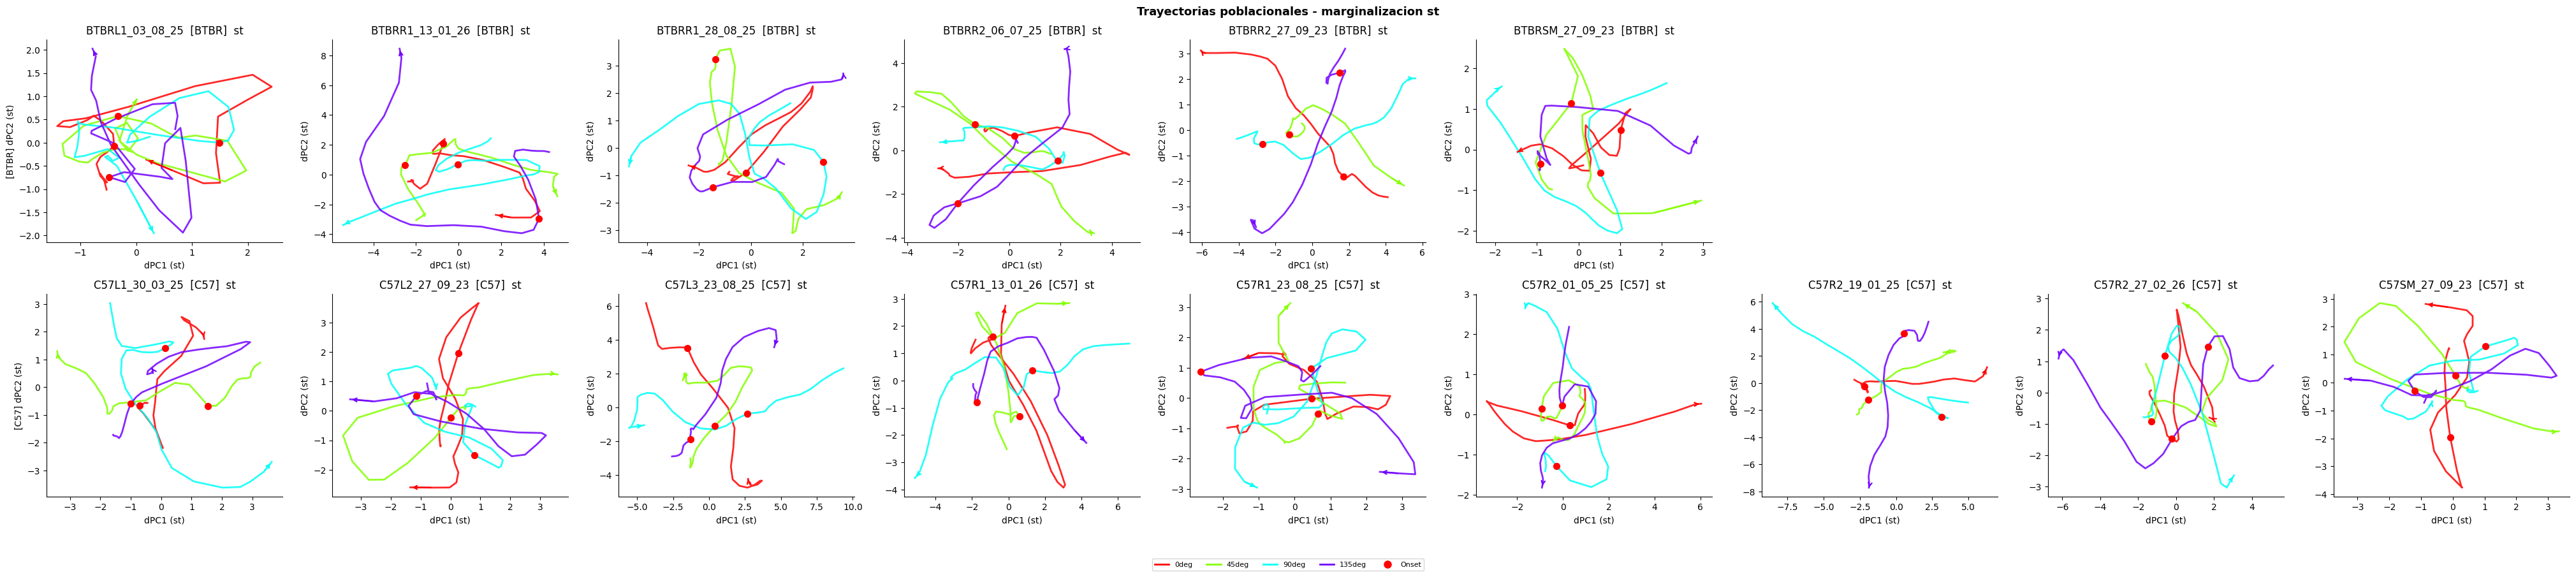

Guardado: dpca_trajectories_st.pdf


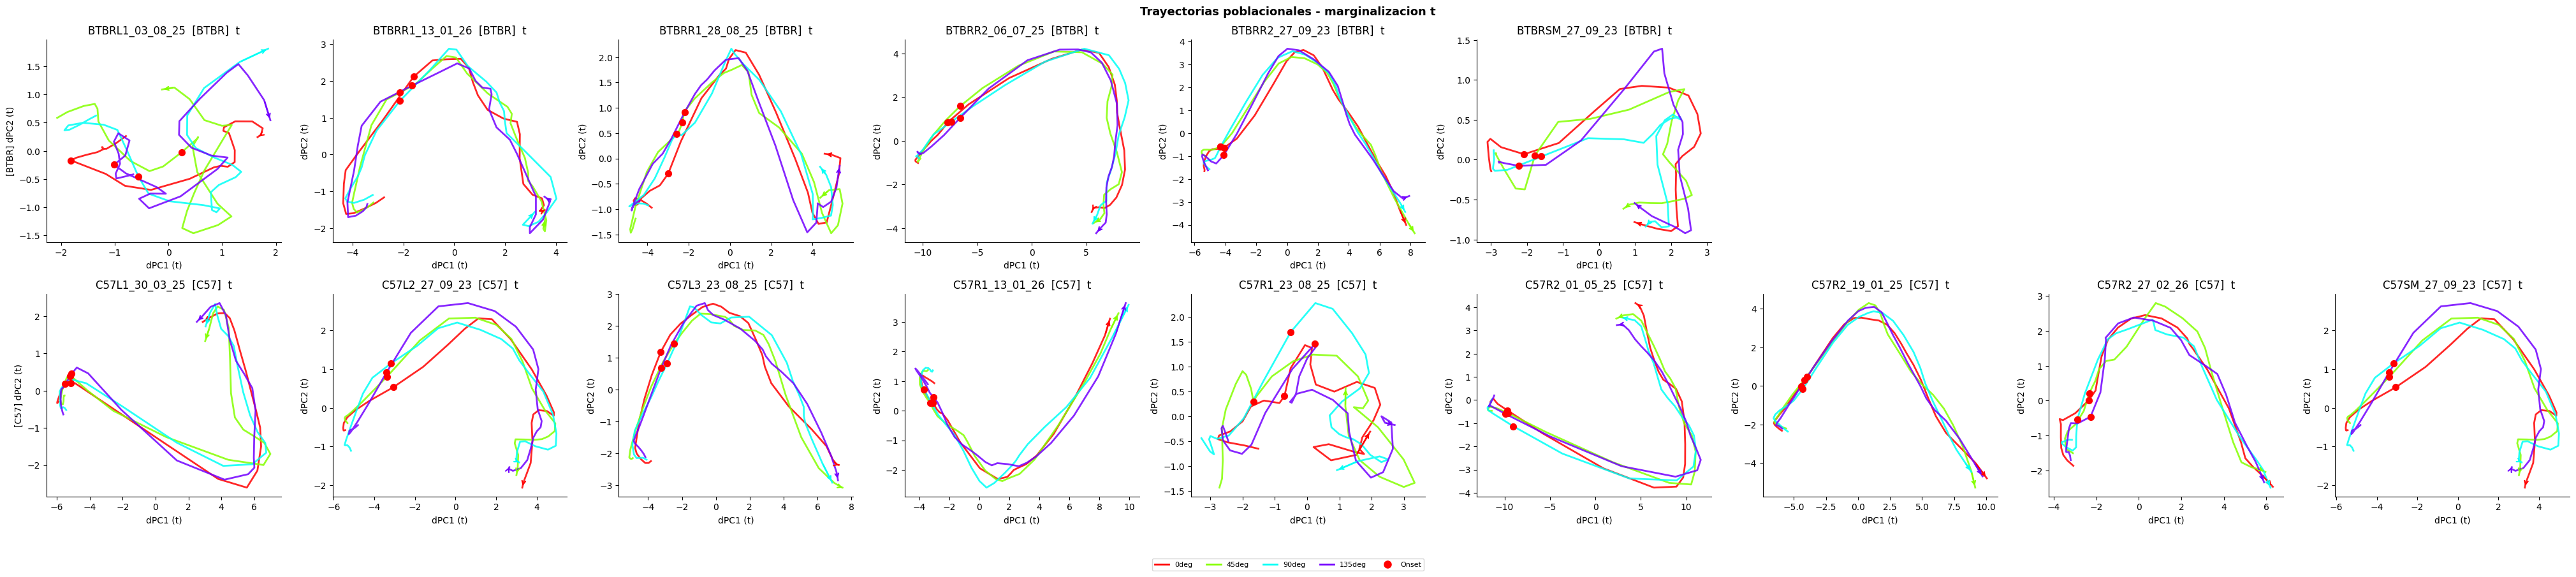

Guardado: dpca_trajectories_t.pdf


In [8]:
def plot_trajectories(aid, tdata, result, marg='st', comp_x=0, comp_y=1, ax=None):
    angles      = tdata['angles']
    n_ang       = len(angles)
    Z           = result['Z'][marg]   # (n_comp, S, T) para 'st', (n_comp, S, T) para 't'
    onset_frame = FRAMES_BEFORE

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    for si, ang in enumerate(angles):
        c = ANGLE_CMAP(si / n_ang)
        x = Z[comp_x, si, :]   # eje 1=estimulo, eje 2=tiempo
        y = Z[comp_y, si, :]
        ax.plot(x, y, color=c, lw=2, label=str(ang) + 'deg', alpha=0.85)
        ax.annotate('', xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

    # Punto de onset: para cada estimulo, el frame de onset
    ax.scatter([Z[comp_x, si, onset_frame] for si in range(n_ang)],
               [Z[comp_y, si, onset_frame] for si in range(n_ang)],
               color='red', zorder=5, s=50, label='Onset')

    ax.set_xlabel('dPC' + str(comp_x+1) + ' (' + marg + ')')
    ax.set_ylabel('dPC' + str(comp_y+1) + ' (' + marg + ')')
    ax.set_title(aid + '  [' + tdata['genotype'] + ']  ' + marg)
    ax.spines[['top','right']].set_visible(False)

    if standalone:
        ax.legend(fontsize=7, ncol=2)
        plt.tight_layout()
        return fig


# ── grilla por genotipo ──────────────────────────────────────────────────────
genotypes    = sorted(set(t['genotype'] for t in dpca_tensors.values()))
aids_by_geno = {g: [aid for aid, t in dpca_tensors.items() if t['genotype'] == g]
                for g in genotypes}

for marg in ['st', 't']:
    n_rows = len(genotypes)
    n_cols = max(len(v) for v in aids_by_geno.values())

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.5, n_rows*4.5),
                              squeeze=False)

    for gi, geno in enumerate(genotypes):
        for ai, aid in enumerate(aids_by_geno[geno]):
            plot_trajectories(aid, dpca_tensors[aid], all_dpca[aid],
                              marg=marg, ax=axes[gi, ai])
            if ai == 0:
                axes[gi, ai].set_ylabel('[' + geno + '] dPC2 (' + marg + ')')
        for ai in range(len(aids_by_geno[geno]), n_cols):
            axes[gi, ai].set_visible(False)

    # leyenda global
    first_aid = list(dpca_tensors.keys())[0]
    ang_list  = dpca_tensors[first_aid]['angles']
    n_ang     = len(ang_list)
    handles   = [plt.Line2D([0],[0], color=ANGLE_CMAP(i/n_ang), lw=2,
                             label=str(a)+'deg') for i, a in enumerate(ang_list)]
    handles.append(plt.Line2D([0],[0], marker='o', color='red', lw=0, ms=8, label='Onset'))
    fig.legend(handles=handles, fontsize=8, ncol=len(handles),
               loc='lower center', bbox_to_anchor=(0.5, -0.01))

    title = 'Trayectorias poblacionales - marginalizacion ' + marg
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(OUTPUT_DIR / ('dpca_trajectories_' + marg + '.pdf'), bbox_inches='tight')
    plt.show()
    print('Guardado: dpca_trajectories_' + marg + '.pdf')


## 8. Cursos temporales y varianza explicada

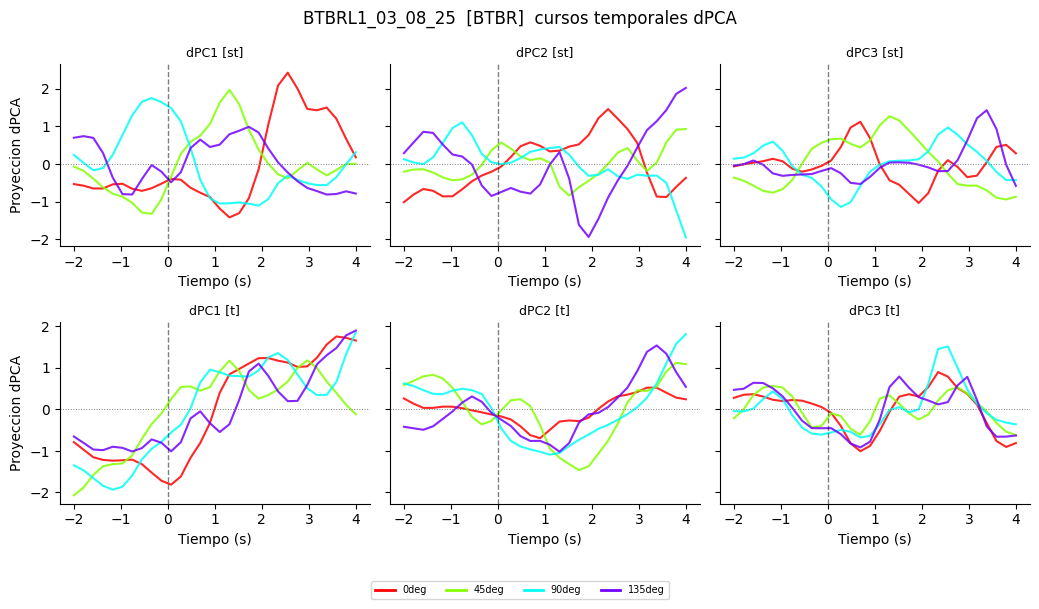

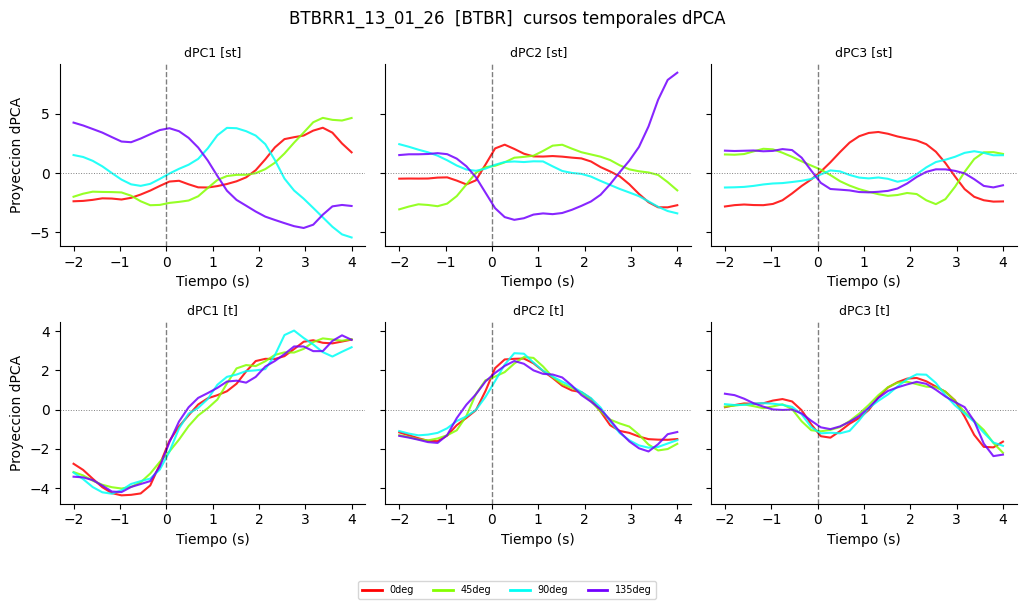

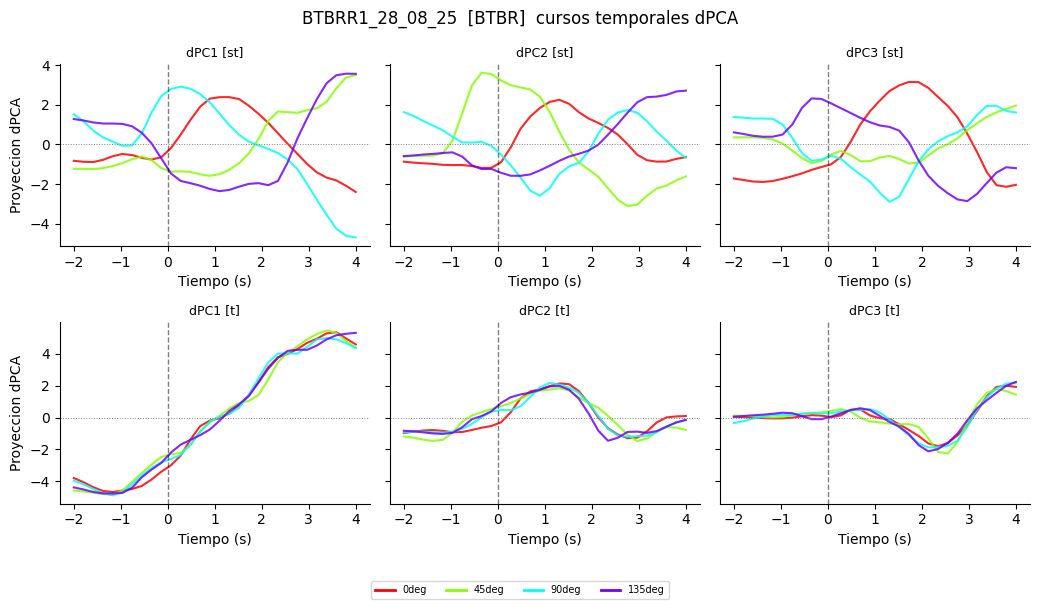

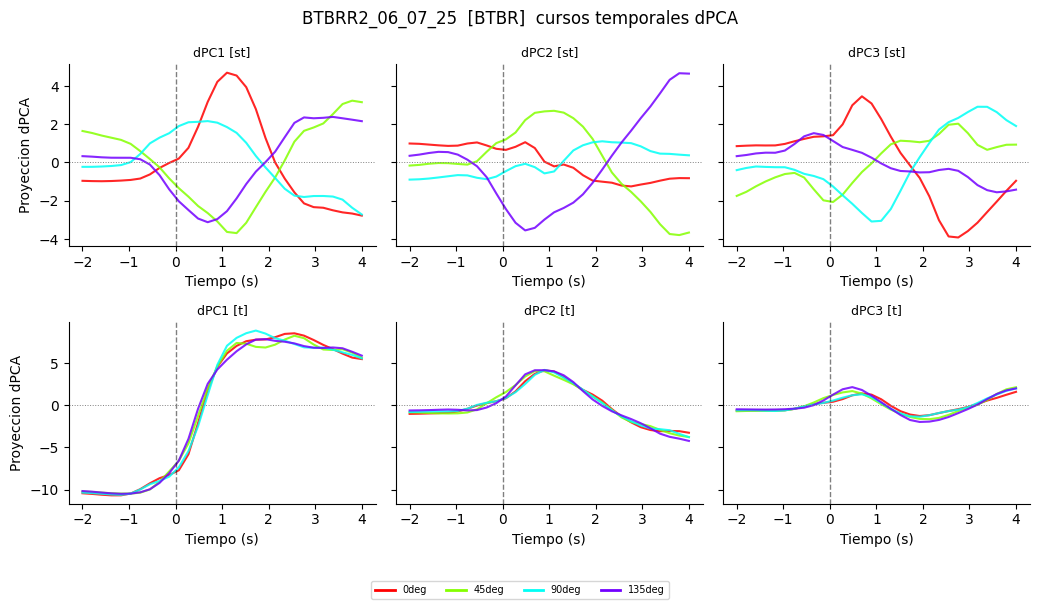

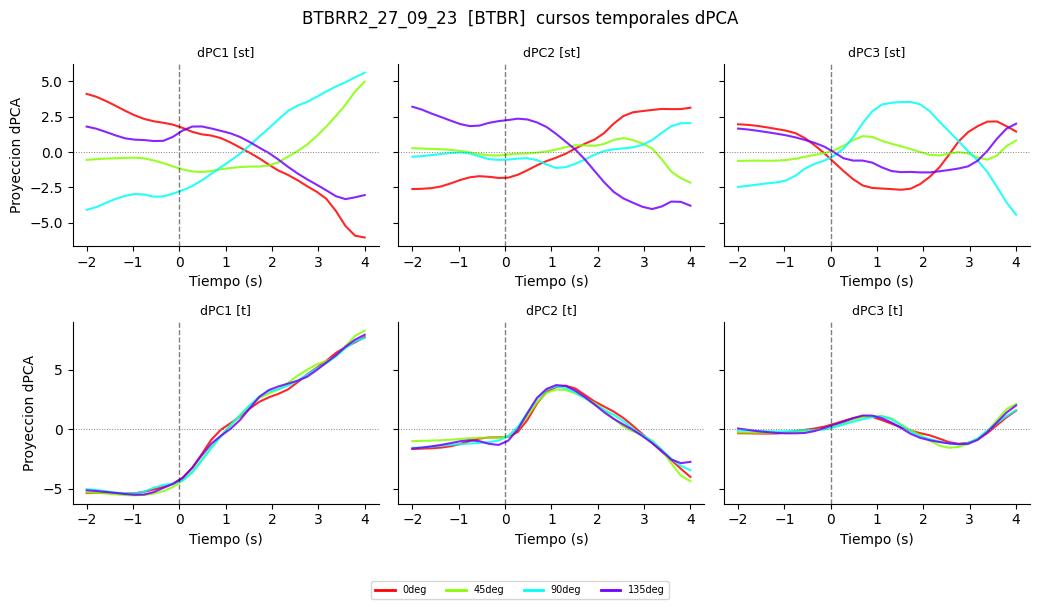

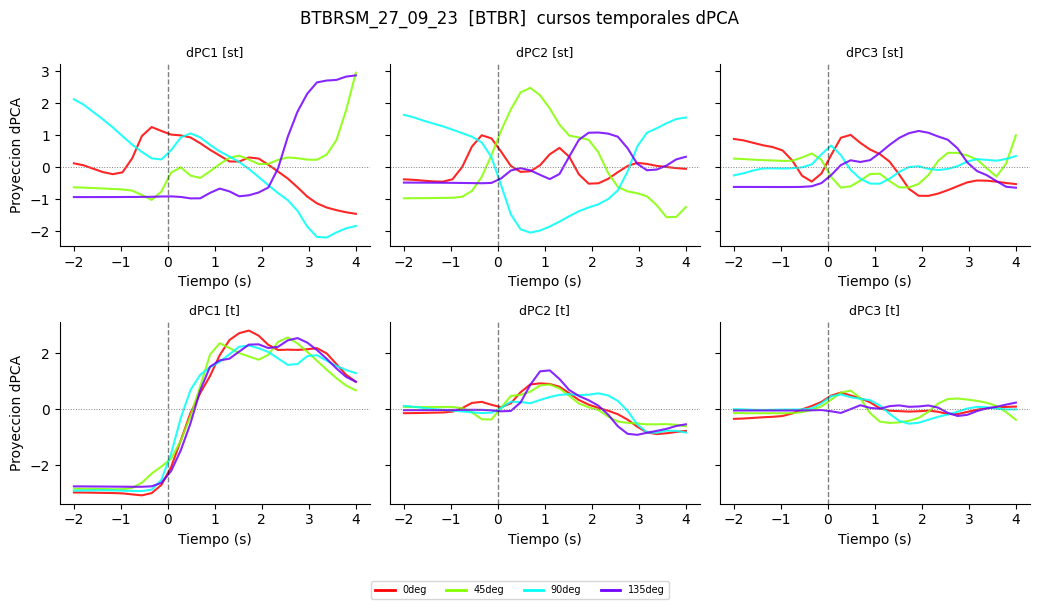

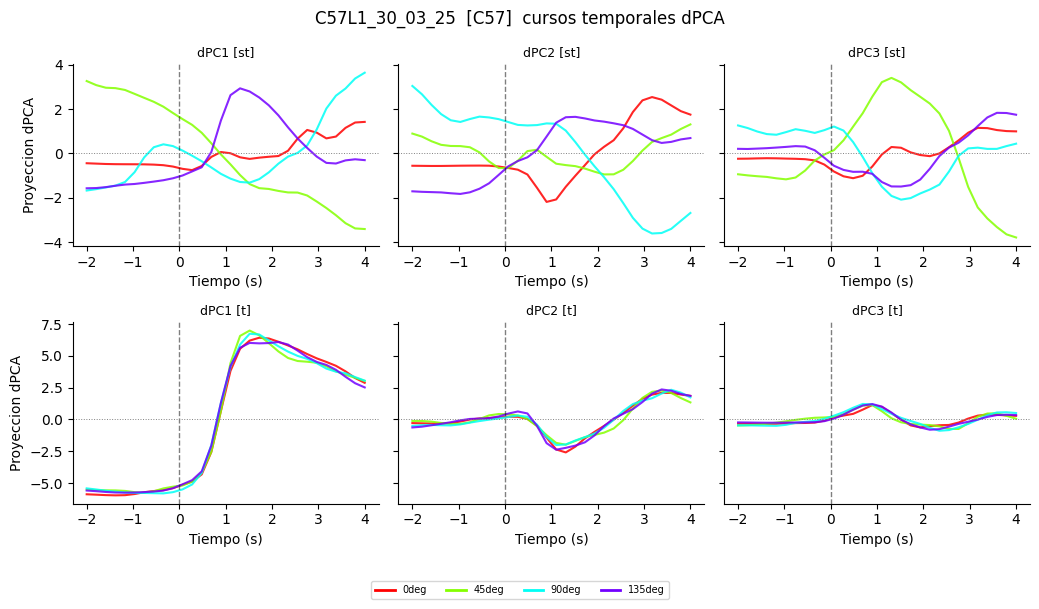

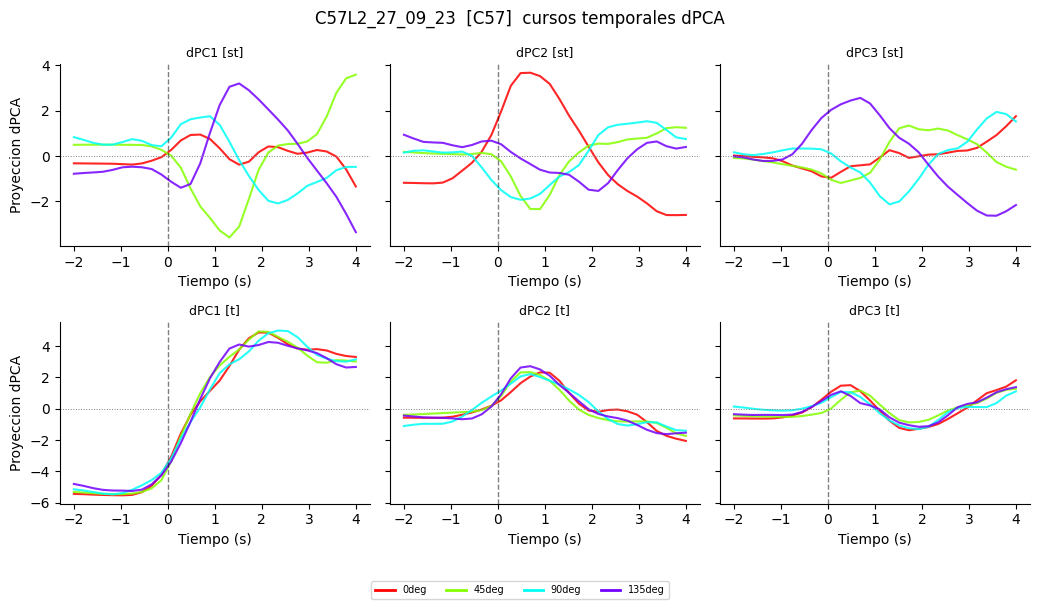

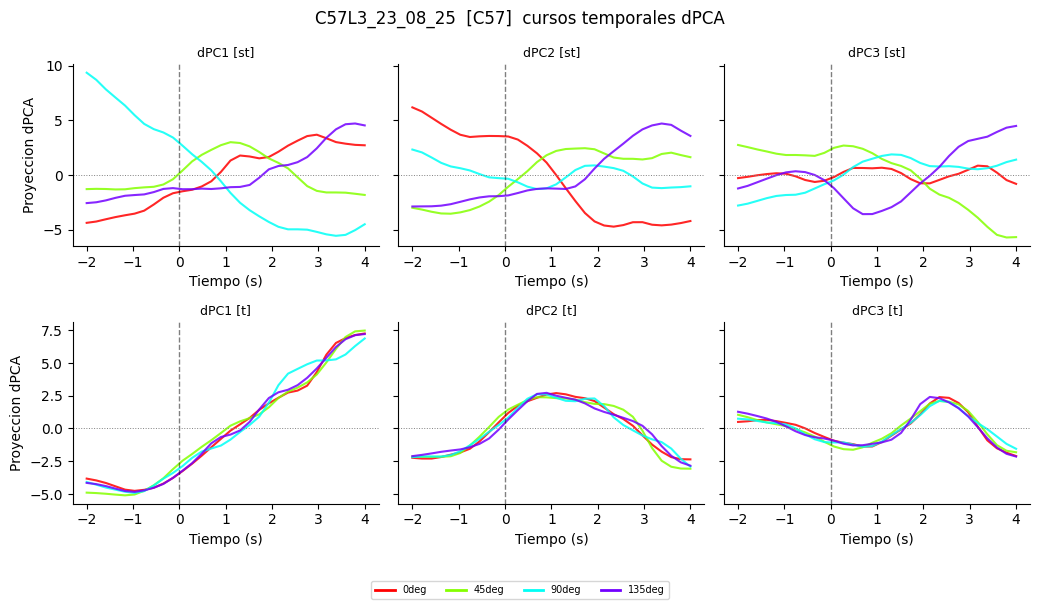

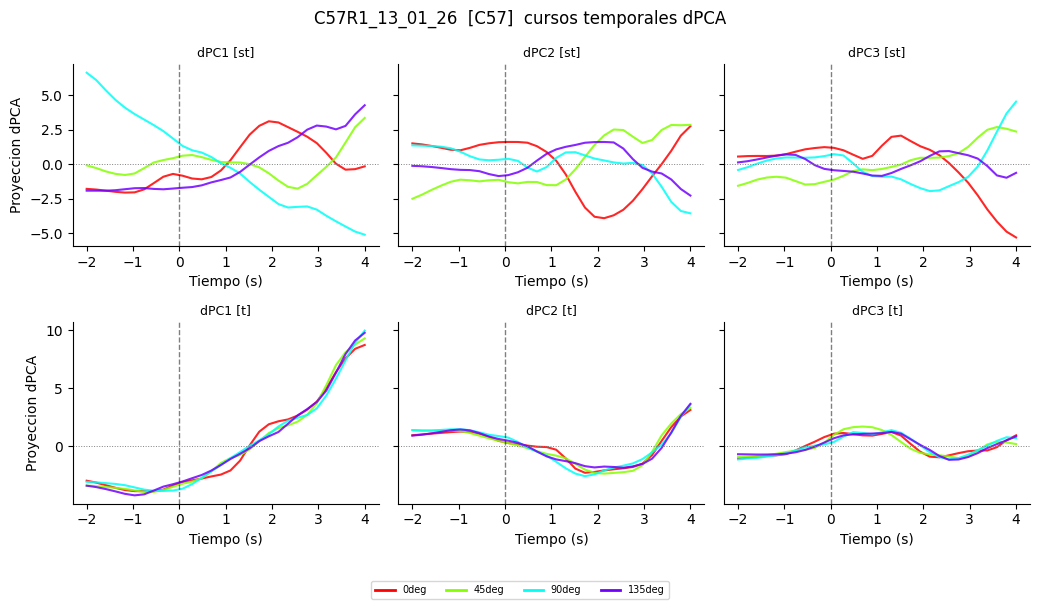

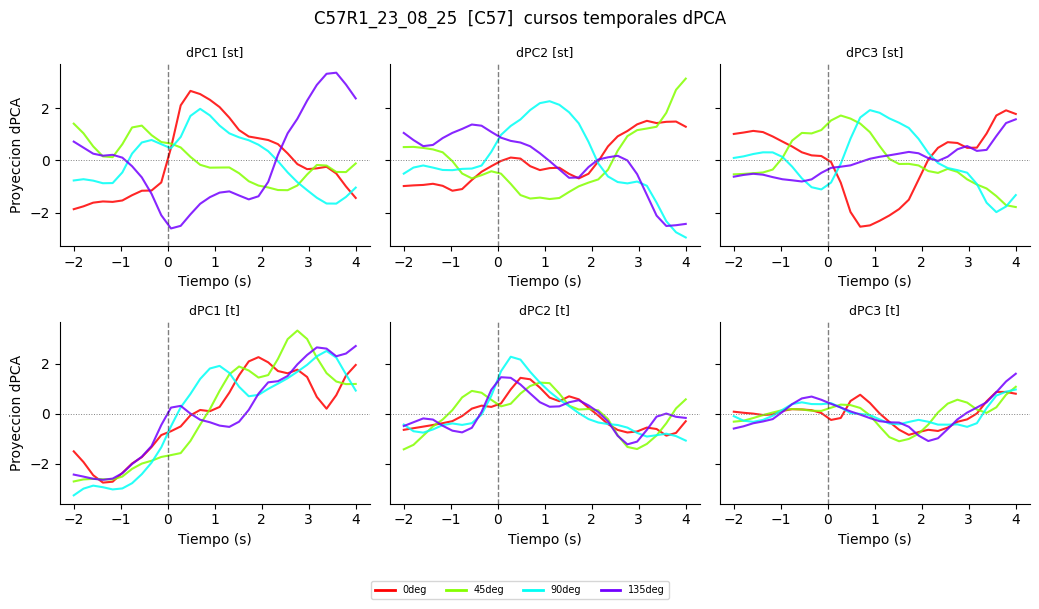

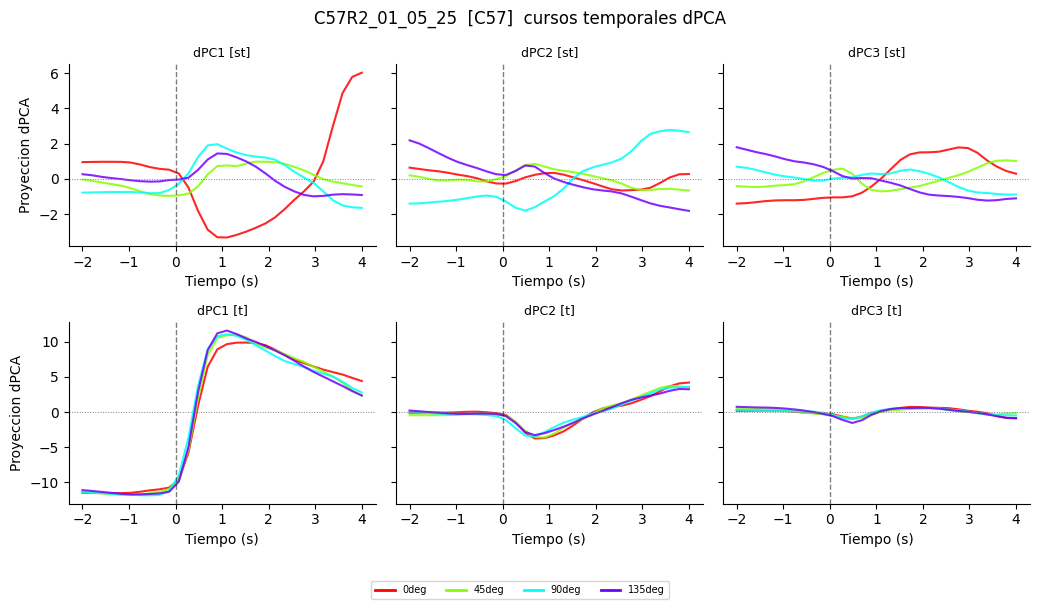

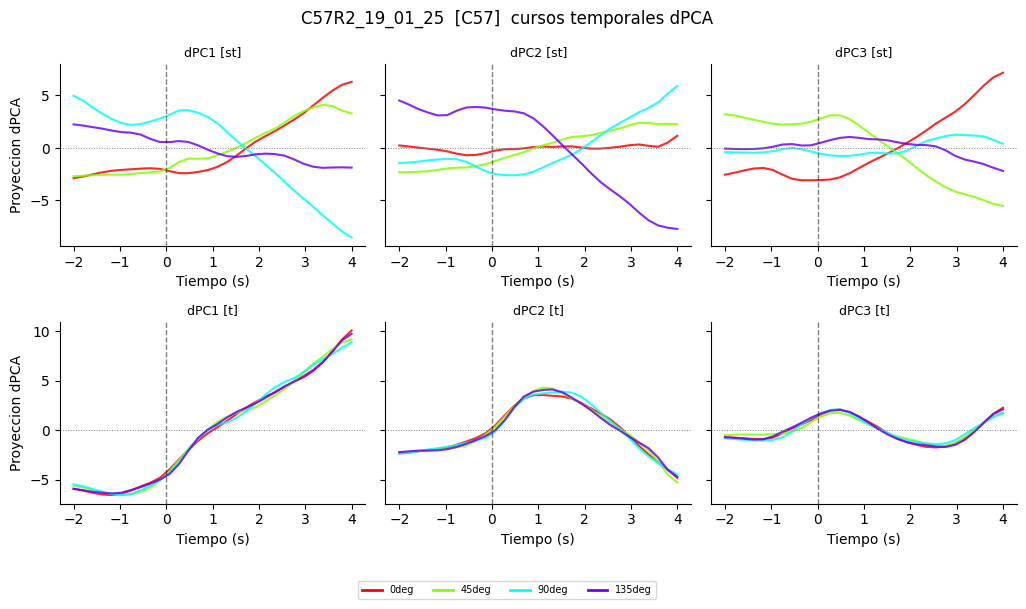

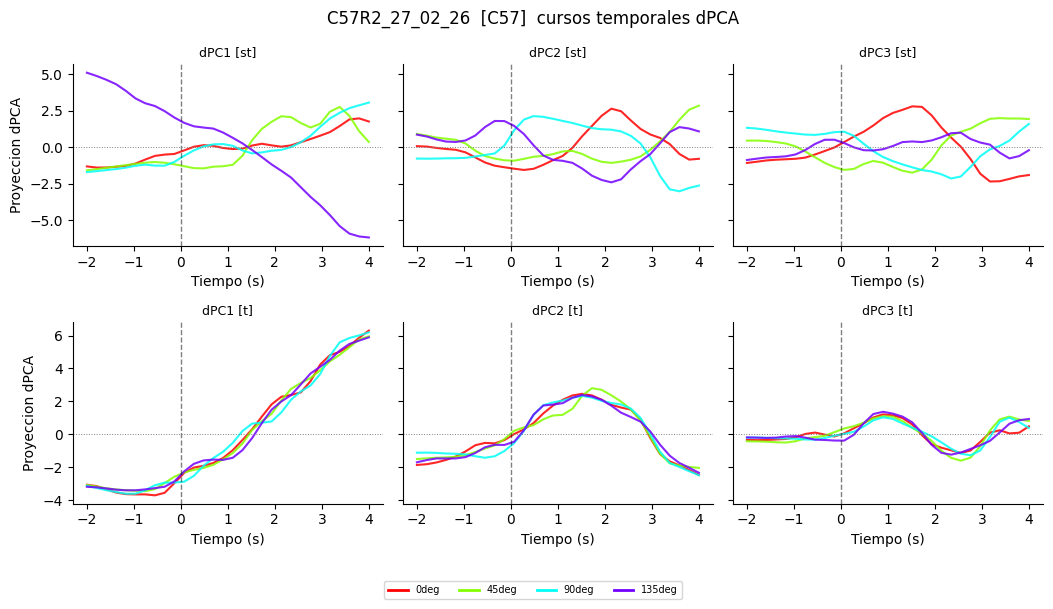

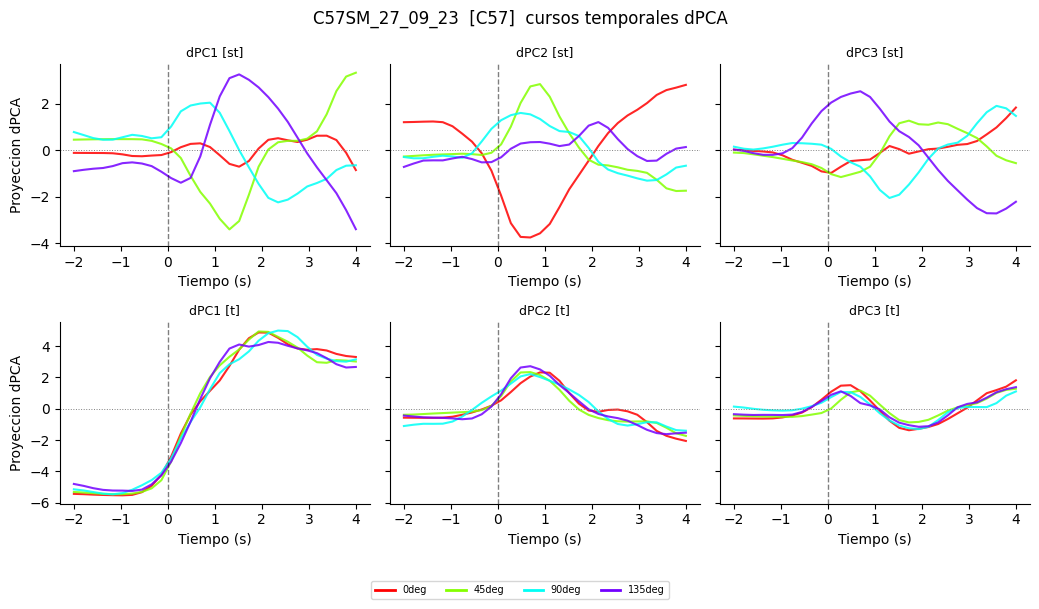

,animal_id,genotype,var_s,var_t,var_st
0,BTBRL1_03_08_25,BTBR,0.0,34.85,28.99
1,BTBRR1_13_01_26,BTBR,0.0,24.72,29.85
2,BTBRR1_28_08_25,BTBR,0.0,42.68,21.66
3,BTBRR2_06_07_25,BTBR,0.0,57.35,7.48
4,BTBRR2_27_09_23,BTBR,0.0,49.09,22.08
5,BTBRSM_27_09_23,BTBR,0.0,59.71,27.89
6,C57L1_30_03_25,C57,0.0,63.61,14.55
7,C57L2_27_09_23,C57,0.0,60.61,15.26
8,C57L3_23_08_25,C57,0.0,27.84,27.58
9,C57R1_13_01_26,C57,0.0,44.33,21.36


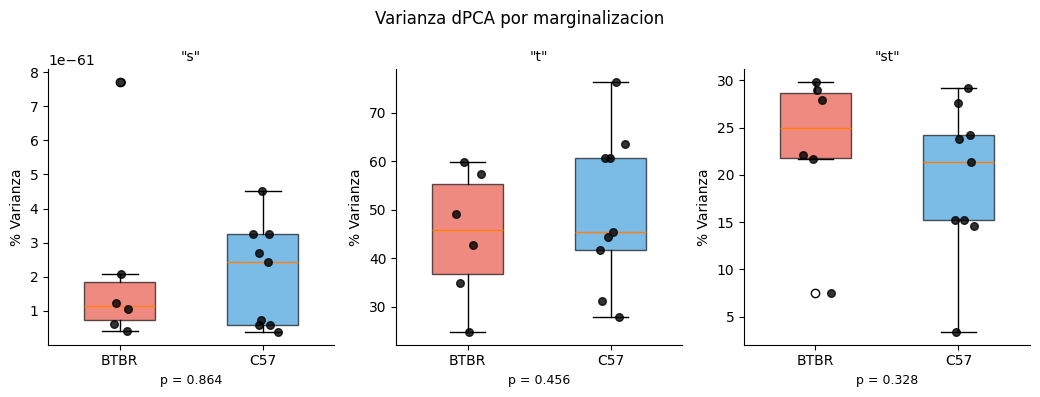

In [9]:
# ── Cursos temporales dPCs ───────────────────────────────────────────────────
for aid, result in all_dpca.items():
    tdata  = dpca_tensors[aid]
    angles = tdata['angles']
    n_ang  = len(angles)
    t_axis = np.linspace(-SEC_BEFORE, SEC_AFTER, tdata['X'].shape[1])

    fig, axes = plt.subplots(2, N_COMPONENTS, figsize=(N_COMPONENTS*3.5, 6), sharey='row')
    title = aid + '  [' + tdata['genotype'] + ']  cursos temporales dPCA'
    fig.suptitle(title, fontsize=12)

    for row, marg in enumerate(['st', 't']):
        Z = result['Z'][marg]
        for ci in range(N_COMPONENTS):
            ax = axes[row, ci]
            for si, ang in enumerate(angles):
                ax.plot(t_axis, Z[ci, si, :], color=ANGLE_CMAP(si/n_ang), lw=1.5, alpha=0.85)
            ax.axvline(0, color='k', ls='--', lw=1, alpha=0.5)
            ax.axhline(0, color='gray', ls=':', lw=0.7)
            ax.set_xlabel('Tiempo (s)')
            ax.set_title('dPC' + str(ci+1) + ' [' + marg + ']', fontsize=9)
            ax.spines[['top','right']].set_visible(False)
            if ci == 0:
                ax.set_ylabel('Proyeccion dPCA')

    handles = [plt.Line2D([0],[0], color=ANGLE_CMAP(i/n_ang), lw=2,
                           label=str(a)+'deg') for i, a in enumerate(angles)]
    fig.legend(handles=handles, fontsize=7, ncol=n_ang, loc='lower center',
               bbox_to_anchor=(0.5, -0.01))
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(OUTPUT_DIR / (aid + '_dpca_timecourses.pdf'), bbox_inches='tight')
    plt.show()


# ── Varianza explicada por genotipo ──────────────────────────────────────────
rows = []
for aid, result in all_dpca.items():
    row = {'animal_id': aid, 'genotype': dpca_tensors[aid]['genotype']}
    for marg, vals in result['var_exp'].items():
        row['var_' + marg] = float(np.sum(vals) * 100)
    rows.append(row)

var_df = pd.DataFrame(rows)
var_df.to_csv(OUTPUT_DIR / 'dpca_variance.csv', index=False)
display(var_df.round(2))

var_cols = [c for c in var_df.columns if c.startswith('var_')]
fig, axes = plt.subplots(1, len(var_cols), figsize=(3.5*len(var_cols), 4))
if len(var_cols) == 1: axes = [axes]

for ax, col in zip(axes, var_cols):
    lbl = col.replace('var_', '')
    groups = [var_df.loc[var_df['genotype']==g, col].values for g in genotypes]
    bp = ax.boxplot(groups, labels=genotypes, patch_artist=True, widths=0.5)
    for patch, g in zip(bp['boxes'], genotypes):
        patch.set_facecolor(PALETTE.get(g,'#95a5a6')); patch.set_alpha(0.65)
    for i, grp in enumerate(groups):
        ax.scatter(np.ones(len(grp))*(i+1) + np.random.normal(0,0.05,len(grp)),
                   grp, color='black', s=30, zorder=4, alpha=0.8)
    ax.set_title('"' + lbl + '"', fontsize=10)
    ax.set_ylabel('% Varianza')
    ax.spines[['top','right']].set_visible(False)
    if len(genotypes) == 2 and all(len(g)>1 for g in groups):
        _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        ax.set_xlabel('p = ' + str(round(p,3)), fontsize=9)

fig.suptitle('Varianza dPCA por marginalizacion', fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'dpca_variance_comparison.pdf', bbox_inches='tight')
plt.show()


## 9. Separacion de trayectorias BTBR vs C57

,animal_id,genotype,mean_traj_dist,intra_spread,norm_separation,var_st,var_s,var_t
0,BTBRL1_03_08_25,BTBR,0.5376,0.9820,0.5474,28.9898,0.0,34.8535
1,BTBRR1_13_01_26,BTBR,1.8915,3.0811,0.6139,29.8524,0.0,24.7217
2,BTBRR1_28_08_25,BTBR,0.9502,2.3961,0.3966,21.6571,0.0,42.6766
3,BTBRR2_06_07_25,BTBR,0.6327,2.6949,0.2348,7.4784,0.0,57.3524
4,BTBRR2_27_09_23,BTBR,2.1891,2.5046,0.8741,22.0818,0.0,49.0871
5,BTBRSM_27_09_23,BTBR,0.8042,1.3394,0.6004,27.8856,0.0,59.7078
6,C57L1_30_03_25,C57,1.5784,1.6839,0.9373,14.5500,0.0,63.6058
7,C57L2_27_09_23,C57,0.5305,1.9650,0.2700,15.2594,0.0,60.6072
8,C57L3_23_08_25,C57,3.5576,2.5974,1.3697,27.5813,0.0,27.8399
9,C57R1_13_01_26,C57,1.9667,2.1680,0.9071,21.3612,0.0,44.3314


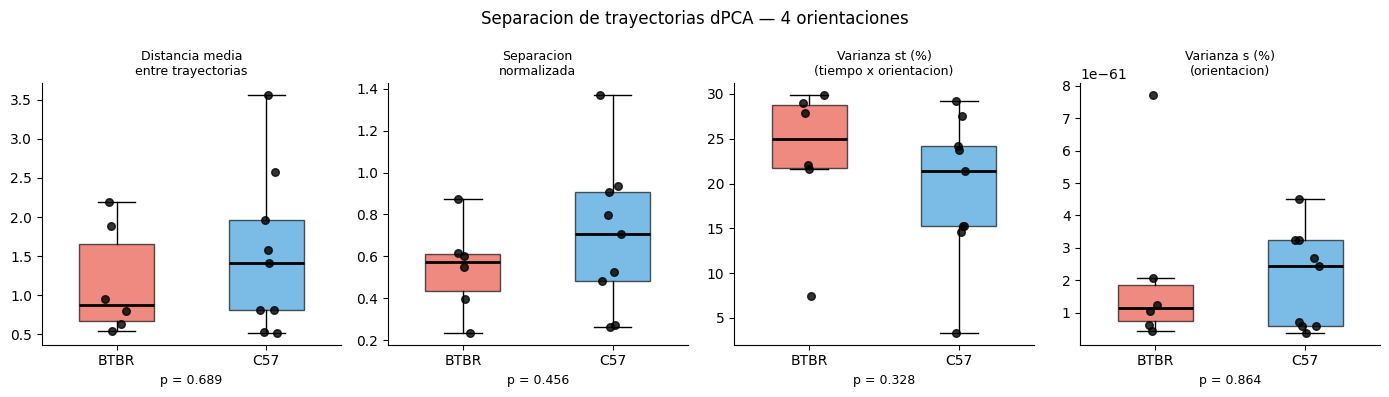

In [11]:
sep_rows = []
for aid, result in all_dpca.items():
    tdata  = dpca_tensors[aid]
    angles = tdata['angles']    # ahora son 4 orientaciones
    geno   = tdata['genotype']

    # Z['st'] shape: (n_comp, S, T)
    if 'st' not in result['Z']:
        print(f'  {aid}: sin componente st')
        continue

    Z_st   = result['Z']['st']                       # (n_comp, S=4, T)
    resp_z = Z_st[:2, :, RESP_START:RESP_END]        # (2, S, T_resp)
    centroids = resp_z.mean(axis=2).T                # (S, 2)

    if len(centroids) < 2:
        continue

    dists = pdist(centroids, metric='euclidean')
    intra = [float(np.mean(np.linalg.norm(
                 resp_z[:, si, :].T - resp_z[:, si, :].mean(axis=1), axis=1)))
             for si in range(len(angles))]

    var_st = float(np.sum(result['var_exp'].get('st', [0])) * 100)
    var_s  = float(np.sum(result['var_exp'].get('s',  [0])) * 100)
    var_t  = float(np.sum(result['var_exp'].get('t',  [0])) * 100)

    sep_rows.append({
        'animal_id':       aid,
        'genotype':        geno,
        'mean_traj_dist':  float(np.mean(dists)),
        'intra_spread':    float(np.mean(intra)),
        'norm_separation': float(np.mean(dists)) / (float(np.mean(intra)) + 1e-10),
        'var_st':          var_st,
        'var_s':           var_s,
        'var_t':           var_t,
    })

sep_df = pd.DataFrame(sep_rows)
sep_df.to_csv(OUTPUT_DIR / 'dpca_separation.csv', index=False)
display(sep_df.round(4))

# ── Boxplot ───────────────────────────────────────────────────────────────────
genotypes = sorted(sep_df['genotype'].unique())
cols_box  = ['mean_traj_dist', 'norm_separation', 'var_st', 'var_s']
labs_box  = ['Distancia media\nentre trayectorias',
             'Separacion\nnormalizada',
             'Varianza st (%)\n(tiempo x orientacion)',
             'Varianza s (%)\n(orientacion)']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col, lbl in zip(axes, cols_box, labs_box):
    groups = [sep_df.loc[sep_df['genotype']==g, col].values for g in genotypes]
    bp = ax.boxplot(groups, labels=genotypes, patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color='black', lw=2))
    for patch, g in zip(bp['boxes'], genotypes):
        patch.set_facecolor(PALETTE.get(g, '#95a5a6'))
        patch.set_alpha(0.65)
    for xi, grp in enumerate(groups):
        ax.scatter(np.ones(len(grp))*(xi+1) + np.random.normal(0, 0.05, len(grp)),
                   grp, color='black', s=30, zorder=4, alpha=0.8)
    ax.set_title(lbl, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if len(genotypes) == 2 and all(len(g) > 1 for g in groups):
        _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
        ax.set_xlabel('p = ' + str(round(p, 3)), fontsize=9)

fig.suptitle('Separacion de trayectorias dPCA — 4 orientaciones', fontsize=12)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'dpca_separation_comparison.svg',
            format='svg', bbox_inches='tight')
plt.show()


In [12]:
for aid, result in all_dpca.items():
    print(aid, list(result['var_exp'].keys()))
    for k, v in result['var_exp'].items():
        print(f'  {k}: {np.sum(v)*100:.2f}%')
    break

BTBRL1_03_08_25 ['s', 't', 'st']
  s: 0.00%
  t: 34.85%
  st: 28.99%


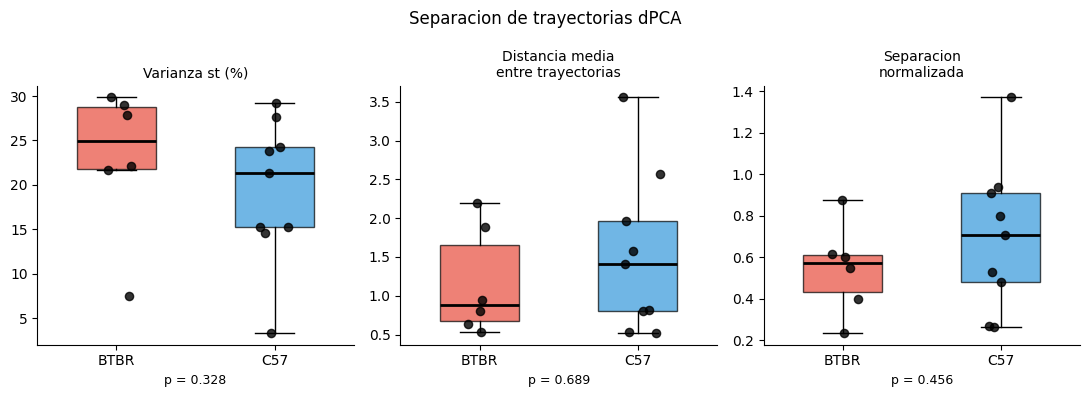

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, col, lbl in zip(axes,
    ['var_st', 'mean_traj_dist', 'norm_separation'],
    ['Varianza st (%)', 'Distancia media\nentre trayectorias', 'Separacion\nnormalizada']):
    groups = [sep_df.loc[sep_df['genotype']==g, col].values
              for g in ['BTBR','C57']]
    bp = ax.boxplot(groups, labels=['BTBR','C57'], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color='black', lw=2))
    for patch, g in zip(bp['boxes'], ['BTBR','C57']):
        patch.set_facecolor(PALETTE[g]); patch.set_alpha(0.7)
    for xi, grp in enumerate(groups):
        ax.scatter(np.ones(len(grp))*(xi+1) + np.random.normal(0,0.05,len(grp)),
                   grp, color='black', s=35, zorder=4, alpha=0.8)
    _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    ax.set_xlabel('p = ' + str(round(p,3)), fontsize=9)
    ax.set_title(lbl, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Separacion de trayectorias dPCA', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpca_separation_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

In [23]:
# ── Concatenar neuronas por genotipo ─────────────────────────────────────────
def build_dpca_tensors_by_genotype(animal_data):
    """
    Construye UN tensor por genotipo concatenando todas las neuronas
    responsivas de todos los animales del genotipo.
    X[n_total, t, s=4] — promedio de trials por orientacion
    X_tr[r_min, n_total, s=4, t] — trials individuales
    """
    sigma_frames = max(1.0, SIGMA_MS / (1000.0 / SAMPLING_RATE))

    # Agrupar por genotipo
    by_geno = {}
    for aid, data in animal_data.items():
        geno = data['genotype']
        by_geno.setdefault(geno, []).append((aid, data))

    out = {}
    for geno, animals_list in by_geno.items():
        print(f'\n{geno}:')
        X_list    = []    # una entrada por animal: (N_resp, T, S)
        X_tr_list = []    # una entrada por animal: (r, N_resp, S, T)
        n_frames  = None
        orientations = None

        for aid, data in animals_list:
            ext  = data['extracted_data']
            resp = data['responsive']
            if not resp:
                print(f'  {aid}: sin responsivas, saltando')
                continue

            resp_arr = np.array(resp)
            ori_data = collapse_to_orientations(ext, resp_arr)
            if len(ori_data) == 0:
                continue

            oris = sorted(ori_data.keys())
            if orientations is None:
                orientations = oris
            elif oris != orientations:
                # Solo usar orientaciones comunes
                oris = sorted(set(oris) & set(orientations))
                orientations = oris

            n_neurons    = len(resp)
            nf           = next(iter(ori_data.values())).shape[1]
            n_trials_min = min(ori_data[o].shape[2] for o in oris)

            if n_frames is None:
                n_frames = nf

            # X[n, t, s] para este animal
            X_a = np.zeros((n_neurons, n_frames, len(oris)))
            for si, ori in enumerate(oris):
                mean_act = np.mean(ori_data[ori], axis=2)   # (N, T)
                mu  = mean_act.mean(axis=1, keepdims=True)
                sd  = mean_act.std(axis=1,  keepdims=True) + 1e-10
                mean_zsc = (mean_act - mu) / sd
                # Restar baseline de cada orientacion para alinear onsets
                baseline_mean = mean_zsc[:, :FRAMES_BEFORE].mean(axis=1, keepdims=True)
                mean_norm = mean_zsc - baseline_mean
                for n in range(n_neurons):
                    X_a[n, :, si] = gaussian_filter1d(mean_norm[n],
                                                       sigma=sigma_frames)
            X_list.append(X_a)

            # X_tr[r, n, s, t] para este animal
            X_tr_a = np.zeros((n_trials_min, n_neurons, len(oris), n_frames))
            for si, ori in enumerate(oris):
                arr = ori_data[ori][:, :, :n_trials_min]
                mu  = arr.mean(axis=1, keepdims=True)
                sd  = arr.std(axis=1,  keepdims=True) + 1e-10
                arr_norm = (arr - mu) / sd
                X_tr_a[:, :, si, :] = arr_norm.transpose(2, 0, 1)
            X_tr_list.append(X_tr_a)

            print(f'  {aid}: {n_neurons} neuronas, {n_trials_min} trials/ori')

        if not X_list:
            print(f'  {geno}: sin datos')
            continue

        # Concatenar neuronas (eje 0)
        X_concat    = np.concatenate(X_list,    axis=0)  # (N_total, T, S)

        # Para X_tr: recortar al minimo de trials entre animales y concatenar
        r_min    = min(x.shape[0] for x in X_tr_list)
        X_tr_cat = np.concatenate(
            [x[:r_min] for x in X_tr_list], axis=1     # (r_min, N_total, S, T)
        )

        out[geno] = {
            'X':            X_concat,
            'X_trials':     X_tr_cat,
            'angles':       orientations,
            'genotype':     geno,
            'n_resp':       X_concat.shape[0],
            'n_trials_min': r_min,
        }
        print(f'  -> X={X_concat.shape}  X_tr={X_tr_cat.shape}')

    return out


print('Construyendo tensores por genotipo...')
dpca_tensors_geno = build_dpca_tensors_by_genotype(animal_data)

Construyendo tensores por genotipo...

BTBR:
  BTBRL1_03_08_25: 7 neuronas, 18 trials/ori
  BTBRR1_13_01_26: 59 neuronas, 6 trials/ori
  BTBRR1_28_08_25: 43 neuronas, 12 trials/ori
  BTBRR2_06_07_25: 139 neuronas, 20 trials/ori
  BTBRR2_27_09_23: 60 neuronas, 16 trials/ori
  BTBRSM_27_09_23: 10 neuronas, 16 trials/ori
  -> X=(318, 30, 4)  X_tr=(6, 318, 4, 30)

C57:
  C57L1_30_03_25: 49 neuronas, 16 trials/ori
  C57L2_27_09_23: 35 neuronas, 16 trials/ori
  C57L3_23_08_25: 91 neuronas, 11 trials/ori
  C57R1_13_01_26: 52 neuronas, 11 trials/ori
  C57R1_23_08_25: 17 neuronas, 10 trials/ori
  C57R2_01_05_25: 130 neuronas, 16 trials/ori
  C57R2_19_01_25: 94 neuronas, 16 trials/ori
  C57R2_27_02_26: 36 neuronas, 11 trials/ori
  C57SM_27_09_23: 35 neuronas, 16 trials/ori
  -> X=(539, 30, 4)  X_tr=(10, 539, 4, 30)


In [24]:
# ── Ajustar dPCA por genotipo ─────────────────────────────────────────────────
all_dpca_geno = {}
for geno, tdata in dpca_tensors_geno.items():
    print(f'{geno} ({tdata["n_resp"]} neuronas)...', end=' ', flush=True)
    try:
        res = fit_dpca(tdata, regularizer=REGULARIZER)
        all_dpca_geno[geno] = res
        ve = {k: round(float(np.sum(v)*100), 2) for k, v in res['var_exp'].items()}
        print('var_exp =', ve)
    except Exception:
        traceback.print_exc()

BTBR (318 neuronas)... var_exp = {'s': 5.3, 't': 30.56, 'st': 4.43}
C57 (539 neuronas)... var_exp = {'s': 4.06, 't': 27.32, 'st': 2.13}


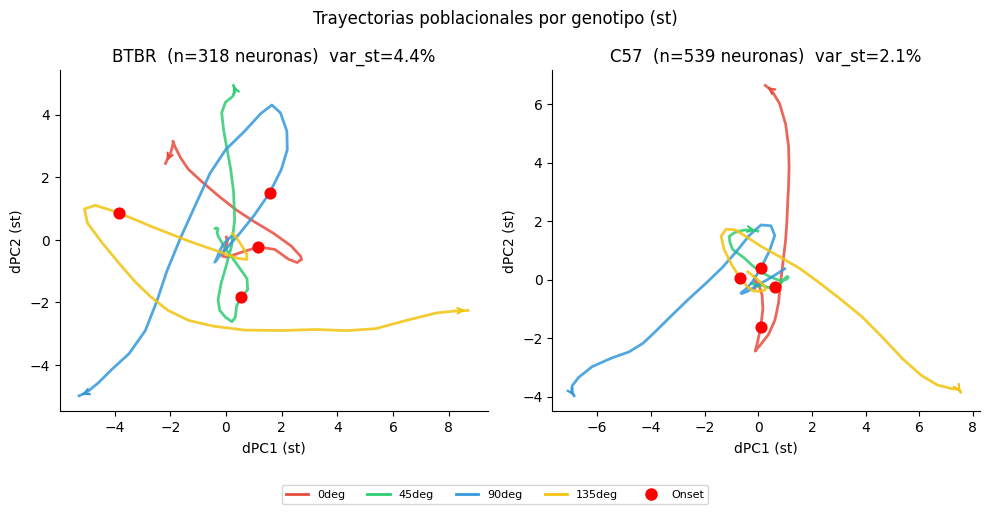

In [25]:
# ── Trayectorias BTBR vs C57 en la misma figura ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Trayectorias poblacionales por genotipo (st)', fontsize=12)

for ax, geno in zip(axes, ['BTBR', 'C57']):
    if geno not in all_dpca_geno:
        continue
    tdata  = dpca_tensors_geno[geno]
    result = all_dpca_geno[geno]
    angles = tdata['angles']
    n_ang  = len(angles)
    Z      = result['Z']['st']              # (n_comp, S, T)

    for si, ang in enumerate(angles):
        c = ORIENT_COLORS.get(ang, ANGLE_CMAP(si / max(n_ang-1, 1)))
        x = Z[0, si, :]
        y = Z[1, si, :]
        ax.plot(x, y, color=c, lw=2, label=str(ang)+'deg', alpha=0.85)
        ax.annotate('', xy=(x[-1], y[-1]), xytext=(x[-2], y[-2]),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

    # Onset
    ax.scatter([Z[0, si, FRAMES_BEFORE] for si in range(n_ang)],
               [Z[1, si, FRAMES_BEFORE] for si in range(n_ang)],
               color='red', zorder=5, s=60)

    ev = result['var_exp']
    var_st = round(float(np.sum(ev.get('st',[0]))*100), 1)
    ax.set_title(geno + '  (n=' + str(tdata['n_resp']) + ' neuronas)' +
                 '  var_st=' + str(var_st) + '%')
    ax.set_xlabel('dPC1 (st)')
    ax.set_ylabel('dPC2 (st)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [plt.Line2D([0],[0], color=ORIENT_COLORS.get(a, 'gray'),
                       lw=2, label=str(a)+'deg')
           for a in dpca_tensors_geno['BTBR']['angles']]
handles.append(plt.Line2D([0],[0], marker='o', color='red', lw=0, ms=8, label='Onset'))
fig.legend(handles=handles, fontsize=8, ncol=5,
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUTPUT_DIR / 'dpca_trajectories_by_genotype.svg',
            format='svg', bbox_inches='tight')
plt.show()

In [26]:
# ── Verificar actividad en baseline por orientación ──────────────────────────
for geno, tdata in dpca_tensors_geno.items():
    X = tdata['X']   # (N, T, S)
    print(geno + ':')
    for si, ori in enumerate(tdata['angles']):
        baseline = X[:, :FRAMES_BEFORE, si]   # (N, frames_before)
        print(f'  {ori}deg  baseline mean={baseline.mean():.4f}  std={baseline.std():.4f}')
    print()

BTBR:
  0deg  baseline mean=0.0056  std=0.2908
  45deg  baseline mean=0.0028  std=0.3641
  90deg  baseline mean=0.0046  std=0.3582
  135deg  baseline mean=0.0059  std=0.3489

C57:
  0deg  baseline mean=0.0036  std=0.2904
  45deg  baseline mean=0.0050  std=0.2838
  90deg  baseline mean=0.0045  std=0.3297
  135deg  baseline mean=0.0034  std=0.3005

